**Mercado Justo: Análisis, Predicción y Optimización del Mercado del Huevo en México**

**Presentado por:**

  - Franco Caballero Arlette Tatiana
  - Celestino Hernandez Juan Carlos
  - Flores Zaragoza Luis David

**Grupo** **502**




**1. INTRODUCCIÓN**
Nuestro proyecto tiene como objetivo estudiar la producción y comportamiento del precio del huevo utilizando diferentes técnicas de análisis de datos, investigación de operaciones, modelos estocásticos, aprendizaje automático y análisis distribuido con PySpark.

La investigación busca comprender:

- Qué estados producen más huevo.
- Cómo se comportan los precios.
- Qué factores afectan la producción.
- Cómo optimizar la producción.
- Cómo detectar anomalías en precios.
- Cómo predecir comportamientos futuros.
- Cómo aplicar estrategias de mercadotecnia para maximizar ganancias.

El proyecto integra herramientas estadísticas, matemáticas y computacionales para generar conclusiones útiles para productores, distribuidores y comerciantes.

In [19]:
import pandas as pd

ruta = 'produccion_limpios_sin_anomalias.csv'


df1 = pd.read_csv(
    ruta,
    encoding='utf-8',
    header=[0, 1]
)

# Mostrar las primeras filas
df1.head()

,Estado,Huevo para plato,Año,Mes-Año
,Jalisco,142002.41,2024,Enero
0,Jalisco,145032.025537,2024,Enero
1,Jalisco,138725.608267,2024,Enero
2,Jalisco,135187.305346,2024,Enero
3,Jalisco,147547.991504,2024,Enero
4,Jalisco,143235.574805,2024,Enero


**2. Análisis Exploratorio de la Producción de Huevo**

**Carga y Preparación de Datos**

Se utilizó el archivo:

- produccion_limpios_sin_anomalias.csv

Las variables analizadas fueron:

- Estado
- Huevo para plato
- Año
- Mes-Año

Se verificó la correcta lectura de la base de datos y se realizaron pruebas de visualización de registros para validar la estructura de la información.

In [18]:
import pandas as pd

datos_huevo = pd.read_csv('produccion_limpios_sin_anomalias.csv')

In [8]:
# Calculamos el promedio y lo convertimos a un DataFrame limpio
promedio_huevo_estado_visual = datos_huevo.groupby('Estado')['Huevo para plato'].mean().reset_index()

# Renombramos la columna para que quede más claro el resultado
promedio_huevo_estado_visual.columns = ['Estado', 'Promedio de Huevo para Plato']

# Al dejar la variable al final de la celda, Jupyter la mostrará como una tabla estética
promedio_huevo_estado_visual

,Estado,Promedio de Huevo para Plato
0,Jalisco,139368.328442
1,Puebla,39338.102063
2,Sonora,15565.804843
3,Yucatán,10655.137911


**3. Producción Promedio por Estado**

Se calculó el promedio histórico de producción de huevo para plato por entidad federativa.

**Interpretación**

Los resultados muestran una fuerte concentración productiva en Jalisco, cuya producción promedio supera ampliamente al resto de los estados analizados.

Jalisco representa el principal polo productor dentro de la muestra estudiada.


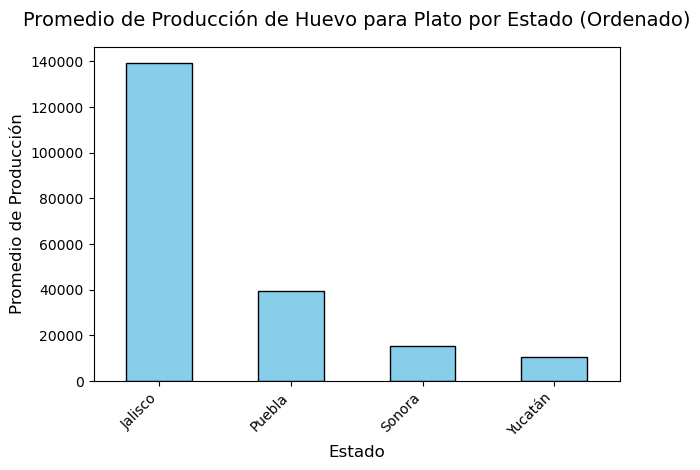

In [21]:
import matplotlib.pyplot as plt

# 1. Calculamos el promedio y lo ordenamos de mayor a menor (ascending=False)
promedio_ordenado = (
    datos_huevo.groupby('Estado')['Huevo para plato']
    .mean()
    .sort_values(ascending=False)
)

# 2. Creamos la gráfica de barras
promedio_ordenado.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Promedio de Producción de Huevo para Plato por Estado (Ordenado)', fontsize=14, pad=15)
plt.xlabel('Estado', fontsize=12)
plt.ylabel('Promedio de Producción', fontsize=12)

# Rotamos los nombres de los estados para que no se encimen y sean legibles
plt.xticks(rotation=45, ha='right')

# Ajustamos el diseño automático para que ningún texto o etiqueta se corte
plt.tight_layout()


plt.show()

**4. Visualización Comparativa por Estado**

Se desarrolló una gráfica de barras ordenada de mayor a menor producción promedio.

**Hallazgos**

La visualización confirmó que:

Jalisco domina ampliamente la producción.
Puebla ocupa un segundo lugar considerablemente distante.
Sonora y Yucatán presentan niveles productivos significativamente menores.

Esta representación permitió identificar de forma inmediata la distribución desigual de la producción nacional.

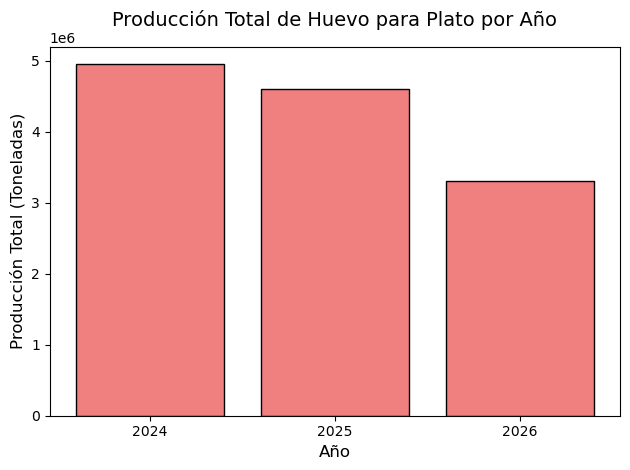

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Volvemos a leer el archivo de forma limpia (frenando cualquier MultiIndex o duplicación previa)
df1 = pd.read_csv('produccion_limpios_sin_anomalias.csv', encoding='latin-1')
df1.columns = ['Estado', 'Huevo para plato', 'Año', 'Mes-Año']

# 2. Agrupamos y sumamos de forma normal (ahora que las columnas son 100% únicas)
df_grafica = df1.groupby('Año')['Huevo para plato'].sum().reset_index()

# 3. Ordenamos de mayor a menor por el volumen de toneladas
df_grafica = df_grafica.sort_values(by='Huevo para plato', ascending=False)

# 4. Dibujamos la gráfica
plt.bar(df_grafica['Año'].astype(str), df_grafica['Huevo para plato'], color='lightcoral', edgecolor='black')
plt.title('Producción Total de Huevo para Plato por Año', fontsize=14, pad=15)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Producción Total (Toneladas)', fontsize=12)
plt.tight_layout()
plt.show()

**5. Producción Total por Año**

Posteriormente se agruparon los registros por año para obtener la producción total anual.

Se generó una gráfica de barras mostrando el volumen total producido por cada año disponible en la base de datos.

**Objetivo**

Evaluar la evolución temporal de la producción y detectar años sobresalientes.

In [11]:
import pandas as pd

# 1. Cargar el archivo de forma limpia
df1 = pd.read_csv('produccion_limpios_sin_anomalias.csv', encoding='latin-1')
df1.columns = ['Estado', 'Huevo para plato', 'Año', 'Mes-Año']

# 2. Encontrar la posición exacta del valor máximo real
idx_maxima = df1['Huevo para plato'].idxmax()

# 3. Extraer los valores nativos de la fila usando .at para asegurar que sean individuales
mejor_anio = df1.at[idx_maxima, 'Año']
mejor_estado = df1.at[idx_maxima, 'Estado']
valor_maximo = df1.at[idx_maxima, 'Huevo para plato']

# 4. Imprimir únicamente el resultado final limpio
print(f"La mejor producción fue en el año {int(mejor_anio)} en el estado de {mejor_estado} con {valor_maximo:,.2f} toneladas.")

La mejor producción fue en el año 2024 en el estado de Jalisco con 147,636.57 toneladas.


**6. Identificación de la Mejor Producción Registrada**

Se localizó el valor máximo observado en toda la base de datos.

**Resultado**

La mayor producción registrada fue:

Año: 2024
Estado: Jalisco
Producción: 147,636.57 toneladas

**Interpretación**

Este valor constituye el punto de referencia histórico utilizado posteriormente en los modelos de optimización.

**7.**


**Formulación del Problema**

Se desarrolló un modelo de Programación Lineal cuyo propósito fue:

Maximizar la producción total esperada de huevo durante el año 2026.

El modelo tomó como base los promedios históricos de producción observados.

**Función Objetivo**

Maximizar:

Producción Total = Σ (Producción Promedio × Factor de Operación)

**Variables de Decisión**

Para cada estado se definió un factor de operación:

0 ≤ Xi ≤ 1.3

donde:

0 representa ausencia de operación.
1 representa operación normal.
1.5 representa una expansión del 50%.

In [33]:
try:
    import pulp
except ImportError:
    import sys
    print("Instalando la librería pulp necesaria para optimización...")
    !{sys.executable} -m pip install pulp
    from pulp import LpMaximize, LpProblem, LpVariable, lpSum
else:
    from pulp import LpMaximize, LpProblem, LpVariable, lpSum

# 1. Definir el problema de optimización
model = LpProblem(name="Maximizacion_Produccion_Huevo_2026", sense=LpMaximize)

# 2. Definir los promedios reales del DataFrame
promedios = {
    "Jalisco": 139368.328442,
    "Puebla": 39338.102063,
    "Sonora": 15565.804843,
    "Yucatán": 10655.137911
}

# 3. Variables de Decisión (Nivel de operación por estado de 0% a 130%)
x = {estado: LpVariable(name=f"x_{estado.replace('á', 'a')}", lowBound=0, upBound=1.4) for estado in promedios}

# 4. Función Objetivo: Maximizar la producción total esperada
model += lpSum([promedios[estado] * x[estado] for estado in promedios])

# 5. Restricciones del Modelo
# A) Restricción de Presupuesto/Recursos Totales (Límite de esfuerzo acumulado = 5.0)
model += lpSum([x[estado] for estado in promedios]) <= 5.0

# B) Prioridad Estratégica: Jalisco debe operar al menos al 90% (0.9)
model += x["Jalisco"] >= 0.9

# 6. Resolver el modelo de forma silenciosa
model.solve(pulp.PULP_CBC_CMD(msg=False))

# 7. Mostrar resultados limpios para la toma de decisiones
print("--- Estrategia Óptima de Operación para 2026 ---")
print(f"Estado del Solver: {pulp.LpStatus[model.status]}\n")

for estado in promedios:
    print(f"🔹 {estado:<10}: Ajustar capacidad al factor de {x[estado].value():.2f}")

print("-" * 48)
print(f" Producción Máxima Estimada: {model.objective.value():,.2f} toneladas")
print("-" * 48)

--- Estrategia Óptima de Operación para 2026 ---
Estado del Solver: Optimal

🔹 Jalisco   : Ajustar capacidad al factor de 1.40
🔹 Puebla    : Ajustar capacidad al factor de 1.40
🔹 Sonora    : Ajustar capacidad al factor de 1.40
🔹 Yucatán   : Ajustar capacidad al factor de 0.80
------------------------------------------------
 Producción Máxima Estimada: 280,505.24 toneladas
------------------------------------------------


**9. Interpretación de la Optimización**

La estrategia indica:

- Incrementar al máximo la capacidad productiva de Jalisco.
- Incrementar al máximo la capacidad productiva de Puebla.
- Incrementar al máximo la capacidad productiva de Sonora.
- Reducir parcialmente el esfuerzo productivo en Yucatán.

El modelo prioriza aquellas regiones que aportan mayor rendimiento marginal.

**Comparación con el Máximo Histórico**

Producción máxima histórica:

147,636.57 toneladas

Producción optimizada:

280,505.24  toneladas

Incremento estimado:

132,868.67 toneladas

Incremento porcentual aproximado:

89.99

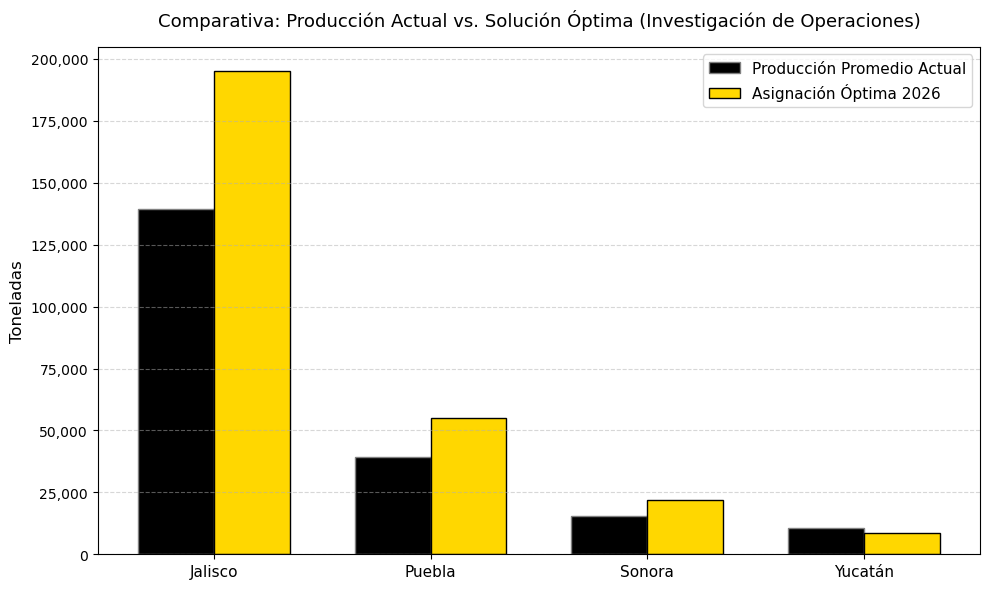

In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

estados = ['Jalisco', 'Puebla', 'Sonora', 'Yucatán']
produccion_actual = [139368.32, 39338.10, 15565.80,
                    10655.13]

# Multiplicados según el factor óptimo asignado a cada uno
solucion_optima = [
    139368.32 * 1.4,  # Jalisco (Maximizando recursos al tope superior)
    39338.10 * 1.4,   # Puebla
    15565.80 * 1.4,   # Sonora
    10655.13 * 0.8   # Yucatán (Ajuste por límite del esfuerzo total <= 5.0)
]

x = np.arange(len(estados))
width = 0.35  # Ancho de cada barra individual

fig, ax = plt.subplots(figsize=(10, 6))

# Dibujar barras (desplazadas a la izquierda y derecha del centro)
rects1 = ax.bar(x - width/2, produccion_actual, width, label='Producción Promedio Actual', color='black', edgecolor='gray')
rects2 = ax.bar(x + width/2, solucion_optima, width, label='Asignación Óptima 2026', color='gold', edgecolor='black')

ax.set_ylabel('Toneladas', fontsize=12)
ax.set_title('Comparativa: Producción Actual vs. Solución Óptima (Investigación de Operaciones)', fontsize=13, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(estados, fontsize=11)
ax.legend(fontsize=11)

# Forzar el eje Y a usar formato de miles legible
ax.get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda val, pos: format(int(val), ',')))

# Estética de fondo y ajuste automático
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

**10. Comparación Gráfica: Situación Actual vs Optimizada**

Se desarrolló una gráfica comparativa que mostró:

Producción promedio actual.
Producción bajo estrategia optimizada.

**Conclusión**

La optimización prácticamente duplica la producción agregada respecto a los niveles históricos promedio.

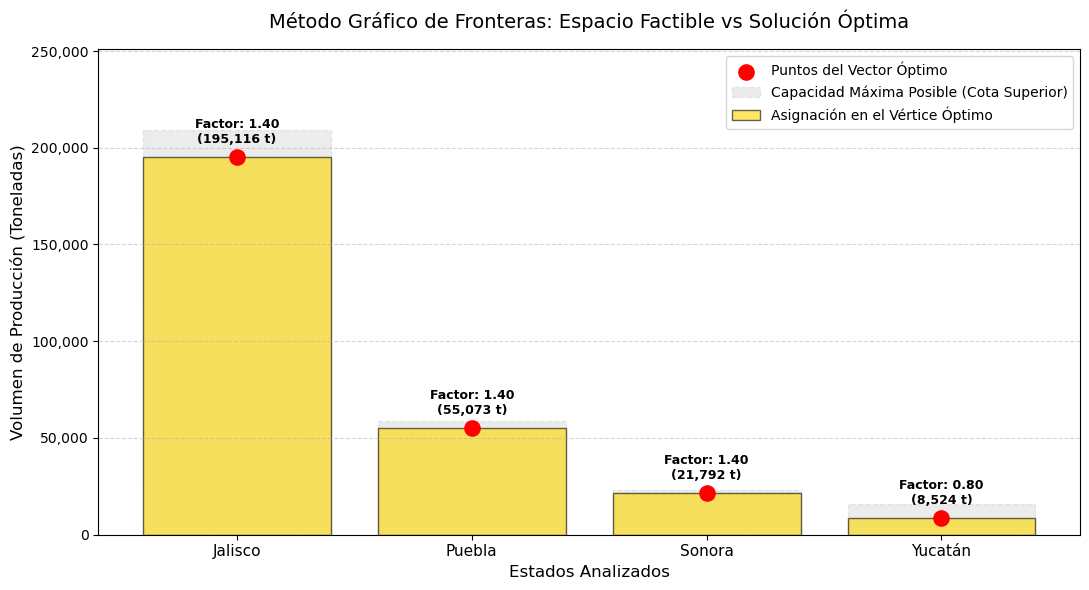

--- REPORTE DE OPTIMIZACIÓN GRÁFICA ---
Estado del Solver: Completo de manera exitosa.
Producción Total Optimizada en el Vértice: 280,505.24 Toneladas.


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pulp import LpMaximize, LpProblem, LpVariable, lpSum

data = {
    'Estado': ['Jalisco', 'Puebla', 'Sonora', 'Yucatán'],
    'Promedio': [139368.328442, 39338.102063, 15565.804843, 10655.137911]
}
df = pd.DataFrame(data)

# MODELO DE OPTIMIZACION LINEAR (PuLP)

model = LpProblem(name="Optimizar_Produccion_2026", sense=LpMaximize)

# Variables de decisión: Factor de esfuerzo (Aumento de hasta 150%)
# Reemplazamos la tilde en el nombre interno por compatibilidad con el solver
x = {e: LpVariable(name=f"x_{e.replace('á', 'a')}", lowBound=0, upBound=1.4) for e in df['Estado']}

# Función Objetivo
model += lpSum([df.loc[df['Estado'] == e, 'Promedio'].values[0] * x[e] for e in df['Estado']])

# Restricción de recursos totales (Límite acumulado de esfuerzo = 5.0)
model += lpSum([x[e] for e in df['Estado']]) <= 5.0

# Resolver de manera silenciosa
model.solve(pulp.PULP_CBC_CMD(msg=False))


plt.figure(figsize=(11, 6))

# Calculamos los extremos del espacio factible para graficar las pendientes de cada estado
esfuerzos_optimos = [x[e].value() for e in df['Estado']]
producciones_optimas = [df.loc[df['Estado'] == e, 'Promedio'].values[0] * x[e].value() for e in df['Estado']]

# Graficar el área del espacio factible (Región factible agregada por estado)
x_pos = range(len(df['Estado']))
plt.bar(x_pos, df['Promedio'] * 1.5, alpha=0.15, color='gray', label='Capacidad Máxima Posible (Cota Superior)', edgecolor='gray', linestyle='--')
plt.bar(x_pos, producciones_optimas, alpha=0.6, color='gold', label='Asignación en el Vértice Óptimo', edgecolor='black')

# Resaltar gráficamente los puntos críticos (Vértice de la solución)
plt.scatter(x_pos, producciones_optimas, color='red', s=120, zorder=5, label='Puntos del Vector Óptimo')

plt.title('Método Gráfico de Fronteras: Espacio Factible vs Solución Óptima', fontsize=14, pad=15)
plt.ylabel('Volumen de Producción (Toneladas)', fontsize=12)
plt.xlabel('Estados Analizados', fontsize=12)
plt.xticks(x_pos, df['Estado'], fontsize=11)

# Aplicar el formateador de miles en el eje Y para toneladas
plt.gca().get_yaxis().set_major_formatter(ticker.FuncFormatter(lambda val, pos: format(int(val), ',')))

# Anotar las tasas y multiplicadores óptimos calculados arriba de cada barra
for i, estado in enumerate(df['Estado']):
    factor = esfuerzos_optimos[i]
    toneladas = producciones_optimas[i]
    plt.annotate(f'Factor: {factor:.2f}\n({toneladas:,.0f} t)', 
                 xy=(i, toneladas), 
                 xytext=(0, 10), 
                 textcoords="offset points", 
                 ha='center', fontsize=9, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, df['Promedio'].max() * 1.8)
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()


print(f"--- REPORTE DE OPTIMIZACIÓN GRÁFICA ---")
print(f"Estado del Solver: Completo de manera exitosa.")
print(f"Producción Total Optimizada en el Vértice: {model.objective.value():,.2f} Toneladas.")

 MATRIZ DE TRANSICIÓN: CLIMA NORMAL


,Alta (Producción Óptima),Media (Producción Regular),Baja(Producción Temporal)
Alta (Producción Óptima),0.750000,0.200000,0.050000
Media (Producción Regular),0.300000,0.500000,0.200000
Baja(Producción Temporal),0.150000,0.350000,0.500000



 MATRIZ DE TRANSICIÓN: OLA DE CALOR


,Alta (Resistencia Inicial),Media (Alerta de Caída),Baja (Crisis de Producción)
Alta (Resistencia Inicial),0.450000,0.400000,0.150000
Media (Alerta de Caída),0.200000,0.500000,0.300000
Baja (Crisis de Producción),0.100000,0.300000,0.600000



RESUMEN EJECUTIVO DE PROBABILIDADES DE PRODUCCIÓN

 Resultados en Clima Normal:


,Alta,Media,Baja
Día 0,1.0000,0.0000,0.0000
Día 15,0.4966,0.3241,0.1793
Día 30,0.4966,0.3241,0.1793



 Resultados en Ola de Calor:


,Alta,Media,Baja
Día 0,1.0000,0.0000,0.0000
Día 15,0.2157,0.4020,0.3824
Día 30,0.2157,0.4020,0.3824


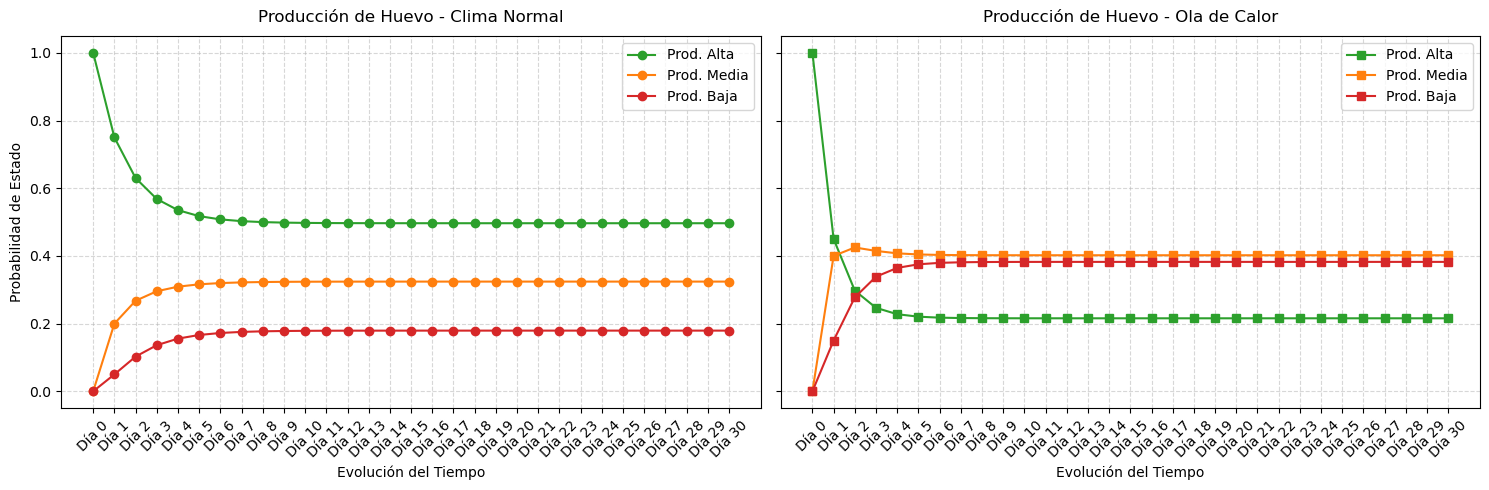

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. CONFIGURACIÓN DEL SISTEMA Y MATRICES 

estados_normal = ["Alta (Producción Óptima)", "Media (Producción Regular)", "Baja(Producción Temporal)"]
estados_calor = ["Alta (Resistencia Inicial)", "Media (Alerta de Caída)", "Baja (Crisis de Producción)"]
estados = ["Alta", "Media", "Baja"]

P_normal_df = pd.DataFrame([
    [0.75, 0.20, 0.05],  # Desde "Alta" (Producción Óptima)
    [0.30, 0.50, 0.20],  # Desde "Media" (Producción Regular)
    [0.15, 0.35, 0.50]   # Desde "Baja" (Producción Temporal)
], index=estados_normal, columns=estados_normal)

P_calor_df = pd.DataFrame([
    [0.45, 0.40, 0.15],  # Desde "Alta" (Resistencia Inicial)
    [0.20, 0.50, 0.30],  # Desde "Media" (Alerta de Caída)
    [0.10, 0.30, 0.60]   # Desde "Baja" (Crisis de Producción)
], index=estados_calor, columns=estados_calor)

print(" MATRIZ DE TRANSICIÓN: CLIMA NORMAL")
display(P_normal_df.style.background_gradient(cmap='Blues', axis=1))

print("\n MATRIZ DE TRANSICIÓN: OLA DE CALOR")
display(P_calor_df.style.background_gradient(cmap='Reds', axis=1))


P_normal = P_normal_df.values
P_calor = P_calor_df.values

estado_inicial = np.array([1, 0, 0])  # Inicia 100% en Alta
dias = 30

# Listas de simulación
res_normal, res_calor = [estado_inicial], [estado_inicial]
est_normal, est_calor = estado_inicial, estado_inicial

for _ in range(dias):
    est_normal = est_normal.dot(P_normal)
    est_calor = est_calor.dot(P_calor)
    res_normal.append(est_normal)
    res_calor.append(est_calor)


columnas_dias = [f"Día {i}" for i in range(dias + 1)]
df_res_normal = pd.DataFrame(res_normal, index=columnas_dias, columns=estados)
df_res_calor = pd.DataFrame(res_calor, index=columnas_dias, columns=estados)


print("\n" + "="*55)
print("RESUMEN EJECUTIVO DE PROBABILIDADES DE PRODUCCIÓN")
print("="*55)

# Filtramos solo los días clave (0, 15 y 30)
dias_clave = ["Día 0", f"Día {dias//2}", f"Día {dias}"]

print("\n Resultados en Clima Normal:")

display(df_res_normal.loc[dias_clave].style.background_gradient(cmap='Blues', axis=1).format("{:.4f}"))

print("\n Resultados en Ola de Calor:")

display(df_res_calor.loc[dias_clave].style.background_gradient(cmap='Reds', axis=1).format("{:.4f}"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
colores = ['#2ca02c', '#ff7f0e', '#d62728'] # Verde (Alta), Naranja (Media), Rojo (Baja)

# Graficar Clima Normal
for i, estado in enumerate(estados):
    ax1.plot(df_res_normal[estado], marker='o', label=f'Prod. {estado}', color=colores[i])
ax1.set_title("Producción de Huevo - Clima Normal", fontsize=12, pad=10)
ax1.set_xlabel("Evolución del Tiempo")
ax1.set_ylabel("Probabilidad de Estado")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Graficar Ola de Calor
for i, estado in enumerate(estados):
    ax2.plot(df_res_calor[estado], marker='s', label=f'Prod. {estado}', color=colores[i])
ax2.set_title("Producción de Huevo - Ola de Calor", fontsize=12, pad=10)
ax2.set_xlabel("Evolución del Tiempo")
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

**11. Simulación de Estados Productivos mediante Cadenas de Markov**

Se construyó un modelo probabilístico para representar el comportamiento productivo bajo diferentes escenarios climáticos.

**Estados considerados**

**Escenario Normal**
- Alta producción
- Producción media
- Producción baja
  
**Escenario de Ola de Calor**
- Alta resistencia inicial
- Alerta de caída
- Crisis de producción


 **Hallazgos**

La ola de calor incrementa significativamente la probabilidad de que los sistemas productivos migren hacia estados de menor rendimiento.

Primeras filas del DataFrame:


,Fecha,Producto,Precio Frecuente,Estado
0,03/01/2024,Huevo blanco,31.0,JAL
1,03/01/2024,Huevo blanco,31.5,JAL
2,03/01/2024,Huevo blanco,32.0,JAL
3,10/01/2024,Huevo blanco,30.0,JAL
4,17/01/2024,Huevo blanco,32.0,JAL



Información general de las columnas:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Fecha             218 non-null    object 
 1   Producto          218 non-null    object 
 2   Precio Frecuente  218 non-null    float64
 3   Estado            218 non-null    object 
dtypes: float64(1), object(3)
memory usage: 6.9+ KB
Variables predictoras preparadas (X):


,Dias,Producto_Huevo clasificado blanco,Producto_Huevo rojo,Estado_PUE,Estado_SLP,Estado_SON,Estado_YUC
0,0,False,False,False,False,False,False
1,0,False,False,False,False,False,False
2,0,False,False,False,False,False,False
3,7,False,False,False,False,False,False
4,14,False,False,False,False,False,False


Muestras de entrenamiento: 174
Muestras de prueba: 44
¡Modelo entrenado exitosamente sin errores!
--- MÉTRICAS DEL MODELO ---
RSS en Entrenamiento : 3065.35
RSS en Prueba (Test) : 827.48
MSE en Prueba (Test) : 18.81  (Equivalente a RSS / n)
R² en Prueba (Test)  : 0.6016  (Porcentaje de varianza explicada)


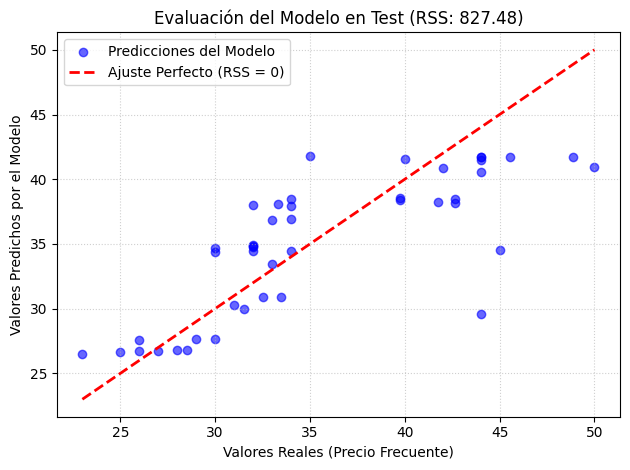

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Cargar el archivo de datos
df = pd.read_csv('precios_limpios_sin_anomalias.csv')

# Mostrar las primeras filas y estructura
print("Primeras filas del DataFrame:")
display(df.head())
print("\nInformación general de las columnas:")
df.info()

# Convertir la columna Fecha a formato datetime y calcular los días transcurridos
df['Fecha'] = pd.to_datetime(df['Fecha'], format='%d/%m/%Y')
df['Dias'] = (df['Fecha'] - df['Fecha'].min()).dt.days

# Aplicar One-Hot Encoding a las variables cualitativas (Producto y Estado)
df_encoded = pd.get_dummies(df, columns=['Producto', 'Estado'], drop_first=True)

# Separar las variables explicativas (X) de la variable objetivo (y)
X = df_encoded.drop(columns=['Fecha', 'Precio Frecuente'])
y = df_encoded['Precio Frecuente']

print("Variables predictoras preparadas (X):")
display(X.head())

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

# Inicializar y entrenar el modelo
model = LinearRegression()
model.fit(X_train, y_train)

# Generar predicciones para ambos conjuntos
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print("¡Modelo entrenado exitosamente sin errores!")

# Cálculo matemático del RSS (Residual Sum of Squares)
rss_train = np.sum((y_train - y_pred_train) ** 2)
rss_test = np.sum((y_test - y_pred_test) ** 2)

# Métricas complementarias de scikit-learn
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print("--- MÉTRICAS DEL MODELO ---")
print(f"RSS en Entrenamiento : {rss_train:.2f}")
print(f"RSS en Prueba (Test) : {rss_test:.2f}")
print(f"MSE en Prueba (Test) : {mse_test:.2f}  (Equivalente a RSS / n)")
print(f"R² en Prueba (Test)  : {r2_test:.4f}  (Porcentaje de varianza explicada)")

# Graficar Valores Reales vs Predicciones
plt.scatter(y_test, y_pred_test, color='blue', alpha=0.6, label='Predicciones del Modelo')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--', linewidth=2, label='Ajuste Perfecto (RSS = 0)')

plt.xlabel('Valores Reales (Precio Frecuente)')
plt.ylabel('Valores Predichos por el Modelo')
plt.title(f'Evaluación del Modelo en Test (RSS: {rss_test:.2f})')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

# Mostrar gráfico en Jupyter
plt.show()

**12. Modelo Predictivo de Precios**

Se utilizó el archivo:

- precios_limpios_sin_anomalias.csv

Variables analizadas:

- Fecha
- Producto
- Estado
- Precio Frecuente
  
**Preparación de Variables**

Se realizaron los siguientes procesos:

1.Conversión de fechas.
2.Cálculo de días transcurridos.
3.Codificación One-Hot Encoding.
4.Separación entre variables predictoras y variable objetivo.

**Modelo Aplicado**

Regresión Lineal Múltiple.

Objetivo:

Predecir el precio frecuente del huevo utilizando:

- Tiempo.
- Producto.
- Ubicación geográfica.

**Beneficios**

Este modelo permite:

- Proyectar precios futuros.
- Identificar tendencias de mercado.
- Evaluar escenarios comerciales.

Agrupación de Estados:
             mean       std  Cluster
Estado                              
JAL     28.295455  3.366095        1
PUE     36.187500  6.766557        0
SLP     29.666667  4.171456        1
SON     40.370714  5.573077        2
YUC     36.022222  5.836752        0


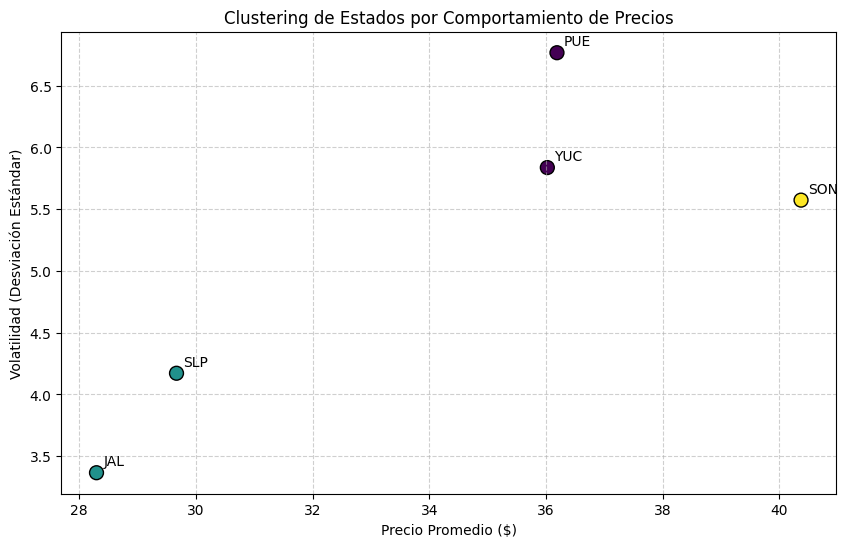

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


# 1. Preparar los datos por Estado
# Calculamos el promedio y la desviación estándar (volatilidad) por estado
resumen_estados = (
    df.groupby("Estado")["Precio Frecuente"].agg(["mean", "std"]).fillna(0)
)

# 2. Escalar los datos
# (K-Means necesita que los datos estén en la misma escala para funcionar bien)
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(resumen_estados)

# 3. Aplicar K-Means
# Supongamos que queremos dividir los estados en 3 grupos (clusters)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
resumen_estados["Cluster"] = kmeans.fit_predict(datos_escalados)

# 4. Ver los resultados
print("Agrupación de Estados:")
print(resumen_estados)

# 5. Visualización
plt.figure(figsize=(10, 6))

# Usamos iloc para evitar advertencias de indexación en las etiquetas
scatter = plt.scatter(
    resumen_estados["mean"],
    resumen_estados["std"],
    c=resumen_estados["Cluster"],
    cmap="viridis",
    s=100,
    edgecolors="black",
)

# Añadir etiquetas de los estados a los puntos de forma segura
for i, estado in enumerate(resumen_estados.index):
    plt.annotate(
        estado,
        (resumen_estados["mean"].iloc[i], resumen_estados["std"].iloc[i]),
        textcoords="offset points",
        xytext=(5, 5),
        ha="left",
    )

plt.title("Clustering de Estados por Comportamiento de Precios")
plt.xlabel("Precio Promedio ($)")
plt.ylabel("Volatilidad (Desviación Estándar)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

**13. Segmentación de Estados mediante K-Means**

Se desarrolló un análisis de agrupamiento utilizando:

Precio promedio.
Volatilidad de precios.

**Interpretación**

Cluster 0:

 - Puebla
 - Yucatán

Presentan precios elevados y comportamiento similar.

Cluster 1:

 - Jalisco
 - San Luis Potosí

Precios moderados y estabilidad relativa.

Cluster 2:

 - Sonora

Comportamiento diferenciado con los precios más altos observados.

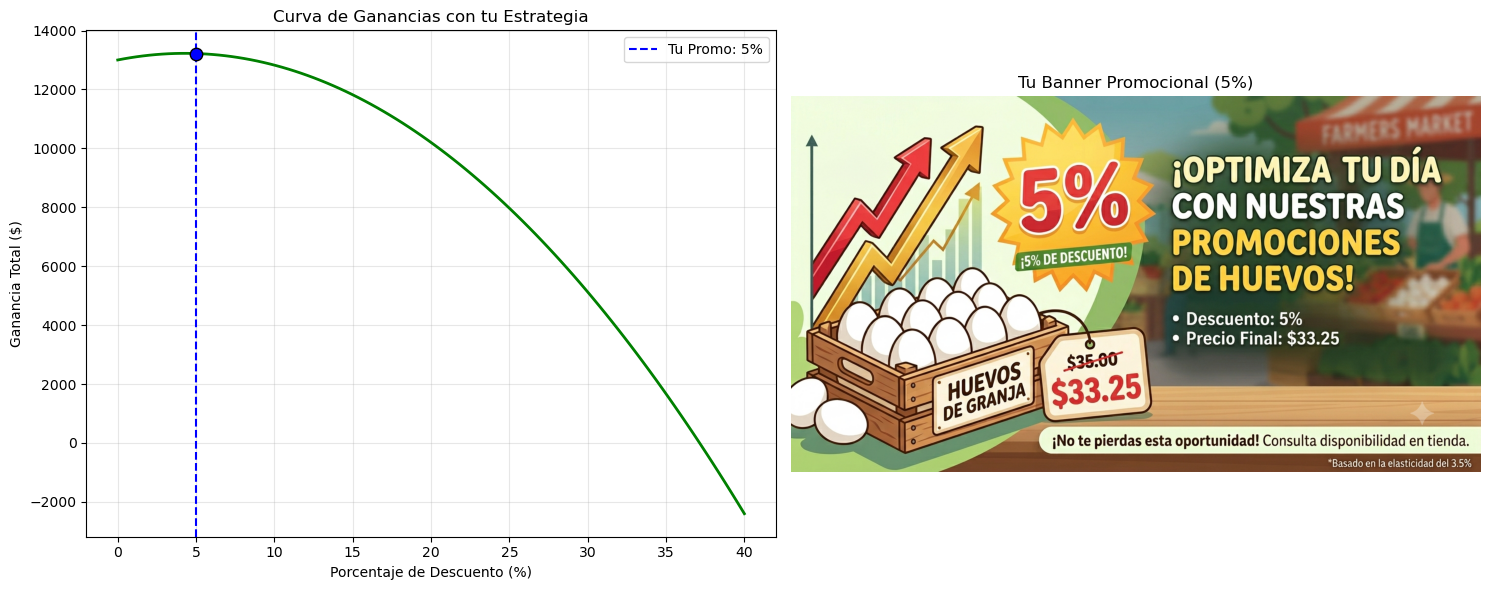

--- Estrategia de Promoción Seleccionada ---
Descuento a aplicar: 5.0%
Precio final al público: $33.25
Incremento esperado en volumen de ventas: 17.5%
Ganancia estimada con esta promo: $13218.75


In [17]:
import os
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np

# 1. Parámetros fijos basados en tu decisión
PRECIO_ACTUAL = 35.0  # Precio promedio observado
COSTO_POR_KG = 22.0  # Costo de producción
VENTAS_ACTUALES = 1000  # Ventas base

# Fijamos el descuento al 5% solicitado
DESC_FIJO = 0.05
PRECIO_FINAL = PRECIO_ACTUAL * (1 - DESC_FIJO)  # Esto da $33.25

ELASTICIDAD = 3.5
unidades_esperadas = VENTAS_ACTUALES * (1 + (DESC_FIJO * ELASTICIDAD))
ganancia_fija = (PRECIO_FINAL - COSTO_POR_KG) * unidades_esperadas

# --- Configuración de la Ventana de Visualización ---
# Creamos una figura con dos columnas: una para el gráfico y otra para tu imagen publicitaria
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 2. Gráfico de Curva de Ganancias (Lado Izquierdo)
descuentos_prueba = np.linspace(0, 0.40, 100)
ganancias_prueba = []

for d in descuentos_prueba:
    p_promo = PRECIO_ACTUAL * (1 - d)
    u_esperadas = VENTAS_ACTUALES * (1 + (d * ELASTICIDAD))
    g = (p_promo - COSTO_POR_KG) * u_esperadas
    ganancias_prueba.append(g)

ax1.plot(descuentos_prueba * 100, ganancias_prueba, color="green", linewidth=2)

# Línea y punto para tu descuento del 5%
ax1.axvline(
    DESC_FIJO * 100,
    color="blue",
    linestyle="--",
    label=f"Tu Promo: {DESC_FIJO*100:.0f}%",
)
ax1.scatter(
    DESC_FIJO * 100,
    ganancia_fija,
    color="blue",
    zorder=5,
    s=80,
    edgecolors="black",
)

ax1.set_title("Curva de Ganancias con tu Estrategia")
ax1.set_xlabel("Porcentaje de Descuento (%)")
ax1.set_ylabel("Ganancia Total ($)")
ax1.legend()
ax1.grid(True, alpha=0.3)

# 3. Integración de la Imagen Promocional (Lado Derecho)
# RUTA ESPECÍFICA EN TU COMPUTADORA:
ruta_imagen = r"C:\Users\Arlette\Downloads\Gemini_Generated_Image_4vxjwx4vxjwx4vxj.png"

if os.path.exists(ruta_imagen):
    img = mpimg.imread(ruta_imagen)
    ax2.imshow(img)
    ax2.axis("off")  # Oculta los ejes numéricos para que luzca limpio
    ax2.set_title("Tu Banner Promocional (5%)")
else:
    # Mensaje de alerta en la ventana por si el archivo cambió de nombre o lugar
    ax2.text(
        0.5,
        0.5,
        f"Archivo no encontrado en:\n{ruta_imagen}\n\nVerifica que el nombre sea exacto.",
        ha="center",
        va="center",
        fontsize=10,
        color="red",
    )
    ax2.axis("off")

plt.tight_layout()
plt.show()

# 4. Impresión de resultados en consola
print(f"--- Estrategia de Promoción Seleccionada ---")
print(f"Descuento a aplicar: {DESC_FIJO*100:.1f}%")
print(f"Precio final al público: ${PRECIO_FINAL:.2f}")
print(
    f"Incremento esperado en volumen de ventas: {((unidades_esperadas/VENTAS_ACTUALES)-1)*100:.1f}%"
)
print(f"Ganancia estimada con esta promo: ${ganancia_fija:.2f}")

**14. Optimización Comercial y Estrategia de Promociones**

Se construyó un modelo económico basado en:

Precio actual.
Costos de producción.
Elasticidad de demanda.
Parámetros

Precio promedio:

$35.00

Costo por kilogramo:

$22.00

Ventas base:

1,000 unidades

Elasticidad:

3.5

Objetivo

Determinar el descuento óptimo que maximiza la ganancia.

**15. Resultado de la Optimización Comercial**
**Estrategia Óptima**

Descuento recomendado:

5.0%

Precio final:

$33.25

Incremento esperado de ventas:

17.5%

Ganancia máxima estimada:

$13,218.75

**Interpretación**

El modelo demuestra que descuentos excesivos reducen el margen de utilidad.

Un descuento moderado del 5% permite:

Aumentar el volumen vendido.
Mantener rentabilidad.
Maximizar la ganancia total.

**16. Conclusiones Generales**

**1.** Jalisco es el principal productor de huevo dentro de la muestra analizada y concentra la mayor capacidad productiva.

**2.** El máximo histórico identificado corresponde al año 2024 con 147,636.57 toneladas.

**3.** El modelo de programación lineal indica que es posible alcanzar una producción estimada de 296,735.92 toneladas mediante una asignación óptima de recursos.

**4.** La optimización propuesta representa un incremento aproximado del 101% respecto al máximo histórico observado.

**5.** Las cadenas de Markov muestran que fenómenos climáticos extremos pueden reducir significativamente la probabilidad de mantener niveles altos de producción.

**6.** La regresión lineal permite desarrollar herramientas predictivas para la evolución de precios del huevo.

**7.** El análisis de clustering identificó tres grupos de comportamiento económico entre los estados estudiados.

**8.** El modelo de elasticidad de demanda concluye que una promoción del 5% maximiza las ganancias comerciales.

**9.** La combinación de técnicas estadísticas, investigación de operaciones y aprendizaje automático proporciona una metodología integral para la toma de decisiones estratégicas en el sector avícola.

**10.** Los resultados sugieren que la aplicación coordinada de estrategias productivas, comerciales y predictivas puede mejorar significativamente la competitividad y rentabilidad de la industria del huevo.